In [27]:
#imported essential libraries
import os
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
#reading the image its size and mode
image = Image.open("FullIJCNN2013/00004.ppm")

print(image.size)
print(image.mode)



(1360, 800)
RGB


In [ ]:
#displaying the first five image
for i in range(6):
    image = Image.open(f'FullIJCNN2013/{i:05d}.ppm')

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title(f"Image {i:05d}")
    plt.axis("off")
    plt.show()

In [4]:
#reading the ground truth file which contains the bounding boxes(annotations) of each traffic sign in the data
gt_path = 'FullIJCNN2013/gt.txt'

with open(gt_path) as f:
    lines = f.readlines()
    
print(lines[:10])

['00000.ppm;774;411;815;446;11\n', '00001.ppm;983;388;1024;432;40\n', '00001.ppm;386;494;442;552;38\n', '00001.ppm;973;335;1031;390;13\n', '00002.ppm;892;476;1006;592;39\n', '00003.ppm;742;443;765;466;4\n', '00003.ppm;742;466;764;489;9\n', '00003.ppm;737;412;769;443;21\n', '00004.ppm;898;342;967;409;21\n', '00004.ppm;906;407;955;459;2\n']


In [5]:
#storing the annotations of traffic signs for first 5  image
res = {}
for i in range(5):
    image_name = f'{i:05d}.ppm'
    annotations = []
    for line in lines:
        parts = line.strip().split(';')
        if parts[0] == image_name:
            annotations.append(parts[1:])
    res[image_name] = annotations
print(res)

{'00000.ppm': [['774', '411', '815', '446', '11']], '00001.ppm': [['983', '388', '1024', '432', '40'], ['386', '494', '442', '552', '38'], ['973', '335', '1031', '390', '13']], '00002.ppm': [['892', '476', '1006', '592', '39']], '00003.ppm': [['742', '443', '765', '466', '4'], ['742', '466', '764', '489', '9'], ['737', '412', '769', '443', '21']], '00004.ppm': [['898', '342', '967', '409', '21'], ['906', '407', '955', '459', '2']]}


In [ ]:
#displaying the bounding boxes for the images checking if the annotations are correct or not 
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

   # change this to your path

for image_name, annotations in res.items():

    # Load image
    image_path = f"FullIJCNN2013/{image_name}"
    image = Image.open(image_path)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 7))

    # Display image
    ax.imshow(image)

    # Draw every bounding box in this image
    for annotation in annotations:

        left = int(annotation[0])
        top = int(annotation[1])
        right = int(annotation[2])
        bottom = int(annotation[3])
        class_id = int(annotation[4])

        width = right - left
        height = bottom - top

        # Bounding box
        rectangle = patches.Rectangle(
            (left, top),
            width,
            height,
            linewidth=0.7,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rectangle)

        # Class name
        ax.text(
            left,
            max(0, top - 5),
            [class_id],
            fontsize=12,
            color="blue",
            fontweight="bold"
        )

    ax.set_title(image_name)
    ax.axis("off")

    plt.show()

In [ ]:
#identifying the traffic signs contained by each image 
image_annotations = {}

for line in lines:
    parts = line.strip().split(";")

    image_name = parts[0]

    if image_name not in image_annotations:
        image_annotations[image_name] = []

    image_annotations[image_name].append(parts[1:])

for image, annotations in image_annotations.items():
        print(image, annotations)

print(len(image_annotations.keys()))

741


In [8]:
#identifying the image the with max no traffic signs
max_signs = max(len(annotations) for annotations in image_annotations.values())

print("Maximum number of signs:", max_signs)

for image, annotations in image_annotations.items():
    if len(annotations) == max_signs:
        print(image)

Maximum number of signs: 6
00073.ppm


In [9]:
#analyzing How many times each ClassID appears in gt.txt across all the traffic-sign annotations.
from collections import Counter

class_count = Counter()

for image, annotations in image_annotations.items():
    for annotation in annotations:
        class_id = int(annotation[-1])
        class_count[class_id] += 1
print(class_count)

Counter({38: 88, 12: 85, 13: 83, 2: 81, 10: 80, 1: 79, 4: 68, 8: 57, 5: 53, 9: 41, 7: 41, 11: 38, 18: 38, 14: 32, 25: 31, 3: 30, 17: 29, 23: 20, 35: 20, 6: 19, 26: 18, 30: 16, 33: 16, 15: 15, 28: 14, 22: 13, 34: 12, 42: 11, 40: 10, 36: 9, 20: 9, 16: 8, 32: 8, 41: 7, 39: 6, 21: 5, 24: 5, 29: 5, 0: 4, 27: 3, 37: 2, 19: 2, 31: 2})


In [10]:
#sorting the dictionary according to classes id and classifying the counts of the classes according 
# there no. of appearances 
res1 = []
res2 = []
for class_id, count in sorted(class_count.items()):
    if count < 10:
        print(f'class {class_id}: {count}')
        res1.append(count)
    else:
        res2.append(count)

print(len(res1))
print(len(res2))
                

class 0: 4
class 16: 8
class 19: 2
class 20: 9
class 21: 5
class 24: 5
class 27: 3
class 29: 5
class 31: 2
class 32: 8
class 36: 9
class 37: 2
class 39: 6
class 41: 7
14
29


In [11]:
#calculating the bounding boxes size 

box_size = []
for image, annotations in image_annotations.items():
    for annotation in annotations:
        left = int(annotation[0])
        top = int(annotation[1])
        right = int(annotation[2])
        bottom = int(annotation[3])

        width = right - left
        height = bottom - top

        box_size.append((image, width, height))


box_size

[('00000.ppm', 41, 35),
 ('00001.ppm', 41, 44),
 ('00001.ppm', 56, 58),
 ('00001.ppm', 58, 55),
 ('00002.ppm', 114, 116),
 ('00003.ppm', 23, 23),
 ('00003.ppm', 22, 23),
 ('00003.ppm', 32, 31),
 ('00004.ppm', 69, 67),
 ('00004.ppm', 49, 52),
 ('00005.ppm', 112, 114),
 ('00006.ppm', 63, 64),
 ('00007.ppm', 39, 39),
 ('00008.ppm', 26, 26),
 ('00008.ppm', 37, 37),
 ('00009.ppm', 24, 24),
 ('00010.ppm', 76, 78),
 ('00011.ppm', 50, 60),
 ('00011.ppm', 70, 77),
 ('00012.ppm', 55, 54),
 ('00013.ppm', 77, 75),
 ('00014.ppm', 20, 19),
 ('00015.ppm', 38, 36),
 ('00016.ppm', 58, 57),
 ('00017.ppm', 123, 106),
 ('00017.ppm', 23, 20),
 ('00018.ppm', 31, 31),
 ('00019.ppm', 58, 56),
 ('00019.ppm', 43, 42),
 ('00020.ppm', 37, 35),
 ('00021.ppm', 52, 49),
 ('00022.ppm', 25, 25),
 ('00023.ppm', 76, 79),
 ('00023.ppm', 90, 94),
 ('00023.ppm', 61, 57),
 ('00024.ppm', 31, 29),
 ('00025.ppm', 41, 37),
 ('00025.ppm', 33, 34),
 ('00026.ppm', 39, 40),
 ('00027.ppm', 55, 55),
 ('00027.ppm', 55, 55),
 ('00028.p

In [15]:
#smallest bounding box size
smallest_box = min(                       
    box_size,
    key=lambda x: x[1] * x[2]
)

print("Smallest bounding box:")
print(smallest_box)


#largest bounding box size
largest_box = max(                          
    box_size,
    key=lambda x: x[1] * x[2]
)

print("Largest bounding box:")
print(largest_box)


#average bounding box size
avg_width = sum(width for image, width, height in box_size) / len(box_size)

avg_height = sum(height for image, width, height in box_size) / len(box_size)

print("Average width:", avg_width)
print("Average height:", avg_height)

Smallest bounding box:
('00536.ppm', 16, 16)
Largest bounding box:
('00755.ppm', 124, 124)
Average width: 43.59934047815334
Average height: 42.86232481450948


In [21]:
#categorizing the bounding boxes into small medium and large 
small = 0
medium = 0
large = 0

for image, width, height in box_size:

    area = width * height

    if area < 1000:
        small += 1

    elif 1000< area < 5000:
        medium += 1

    else:
        large += 1

print("count of bounding boxes with Small area:", small)
print("count of bounding boxes with Medium area:", medium)
print("count of bounding boxes with Large area:", large)

count of bounding boxes with Small area: 424
count of bounding boxes with Medium area: 658
count of bounding boxes with Large area: 131


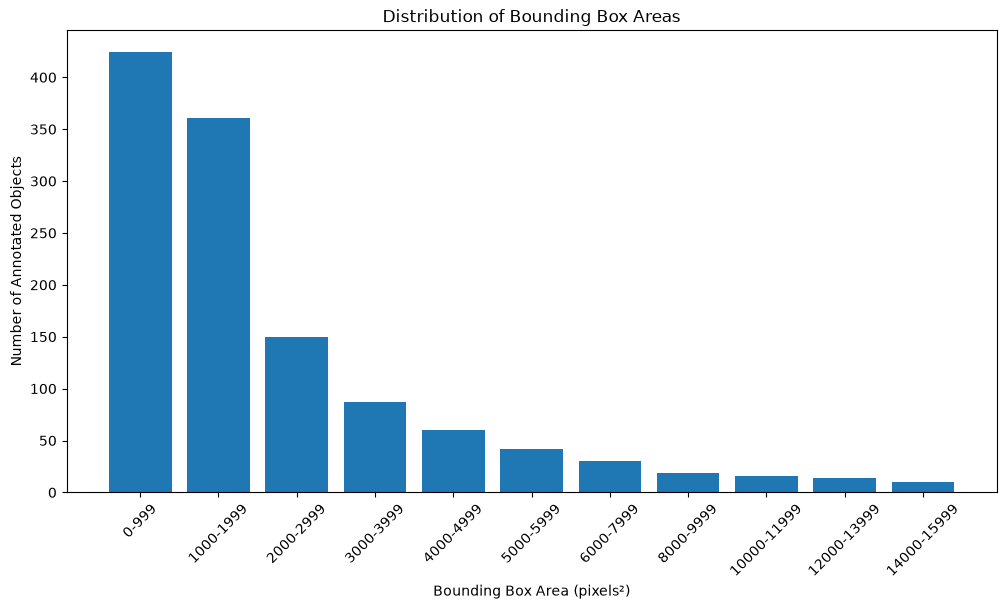

In [24]:
areas = [width * height for image, width, height in box_size]

bins = [0, 1000, 2000, 3000, 4000, 5000, 6000, 8000, 10000, 12000, 14000, 16000]

counts = []

for i in range(len(bins) - 1):
    count = sum(
        bins[i] <= area < bins[i + 1]
        for area in areas
    )
    counts.append(count)

labels = [
    f"{bins[i]}-{bins[i+1]-1}"
    for i in range(len(bins) - 1)
]

plt.figure(figsize=(12, 6))

plt.bar(labels, counts)

plt.xlabel("Bounding Box Area (pixels²)")
plt.ylabel("Number of Annotated Objects")
plt.title("Distribution of Bounding Box Areas")

plt.xticks(rotation=45)

plt.show()

In [13]:
print(image_annotations['00755.ppm'])

for i in box_size:
    if i[0] == '00755.ppm':
        print(i)

[['1084', '294', '1208', '418', '12'], ['852', '518', '883', '549', '1'], ['563', '595', '593', '625', '38']]
('00755.ppm', 124, 124)
('00755.ppm', 31, 31)
('00755.ppm', 30, 30)


In [ ]:
image_path = 'FullIJCNN2013/00755.ppm'

image = Image.open(image_path)

fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(image)

for annotation in image_annotations['00755.ppm']:

    left = int(annotation[0])
    top = int(annotation[1])
    right = int(annotation[2])
    bottom = int(annotation[3])
    class_id = int(annotation[4])

    width = right - left
    height = bottom - top

    rectangle = patches.Rectangle(
        (left, top),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rectangle)

    ax.text(
        left,
        top - 5,
        f"{class_id}",
        color="red",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(image_name)
ax.axis("off")

plt.show()

900


In [ ]:
from sklearn.model_selection import train_test_split

image_names = [file for file in os.listdir('FullIJCNN2013') if file.endswith(".ppm") ]
print(len(image_names))

train_val_images, test_images = train_test_split(
    image_names,
    test_size=0.15,
    random_state=42
)

print("Train + Validation:", len(train_val_images))
print("Test:", len(test_images))

900
Train + Validation: 765
Test: 135


In [31]:
train_images, val_images = train_test_split(
    train_val_images,
    test_size=0.1765,
    random_state=42
)

print('train:', len(train_images))
print('validation:',len(val_images))
print('test:',len(test_images))

train: 629
validation: 136
test: 135
